X shape : (442, 10)
y shape : (442,)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


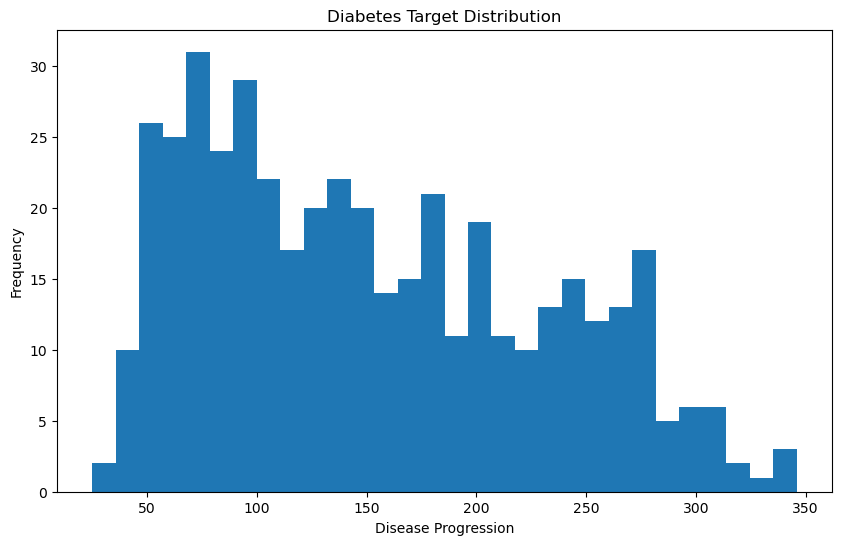

MSE : 2900.193628493482
  Feature  Coefficient
0     age    37.904021
1     sex  -241.964362
2     bmi   542.428759
3      bp   347.703844
4      s1  -931.488846
5      s2   518.062277
6      s3   163.419983
7      s4   275.317902
8      s5   736.198859
9      s6    48.670657


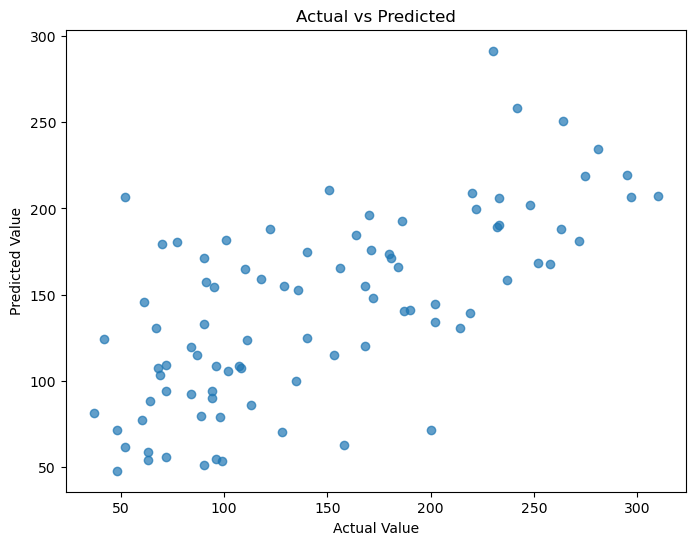

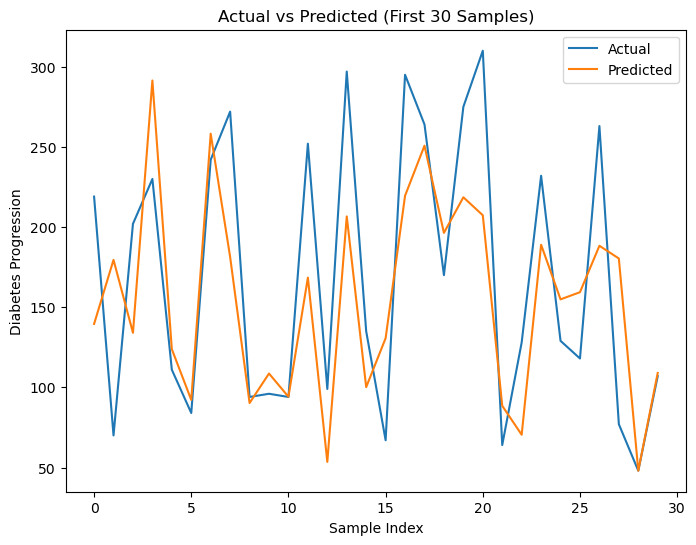

In [2]:
# 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# 당뇨병 데이터셋 불러오기
diabetes = load_diabetes()

# 입력 데이터(X)와 정답 데이터(y) 지정
X = diabetes.data
y = diabetes.target

# 데이터 크기 확인
print("X shape :", X.shape)
print("y shape :", y.shape)

# 데이터프레임으로 변환
df = pd.DataFrame(X, columns=diabetes.feature_names)

# 데이터 확인
print(df.head())

# 타겟 데이터 분포 시각화
plt.figure(figsize=(10, 6))
plt.hist(y, bins=30)
plt.title('Diabetes Target Distribution')
plt.xlabel('Disease Progression')
plt.ylabel('Frequency')
plt.show()

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 선형회귀 모델 생성
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# MSE 계산
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

# 회귀계수 확인
coef_df = pd.DataFrame({
    'Feature': diabetes.feature_names,
    'Coefficient': model.coef_
})

print(coef_df)

# 실제값과 예측값 비교 시각화
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Predicted')

plt.show()

# 실제값과 예측값 차이 확인
plt.figure(figsize=(8, 6))

plt.plot(y_test[:30], label='Actual')
plt.plot(y_pred[:30], label='Predicted')

plt.title('Actual vs Predicted (First 30 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Diabetes Progression')

plt.legend()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


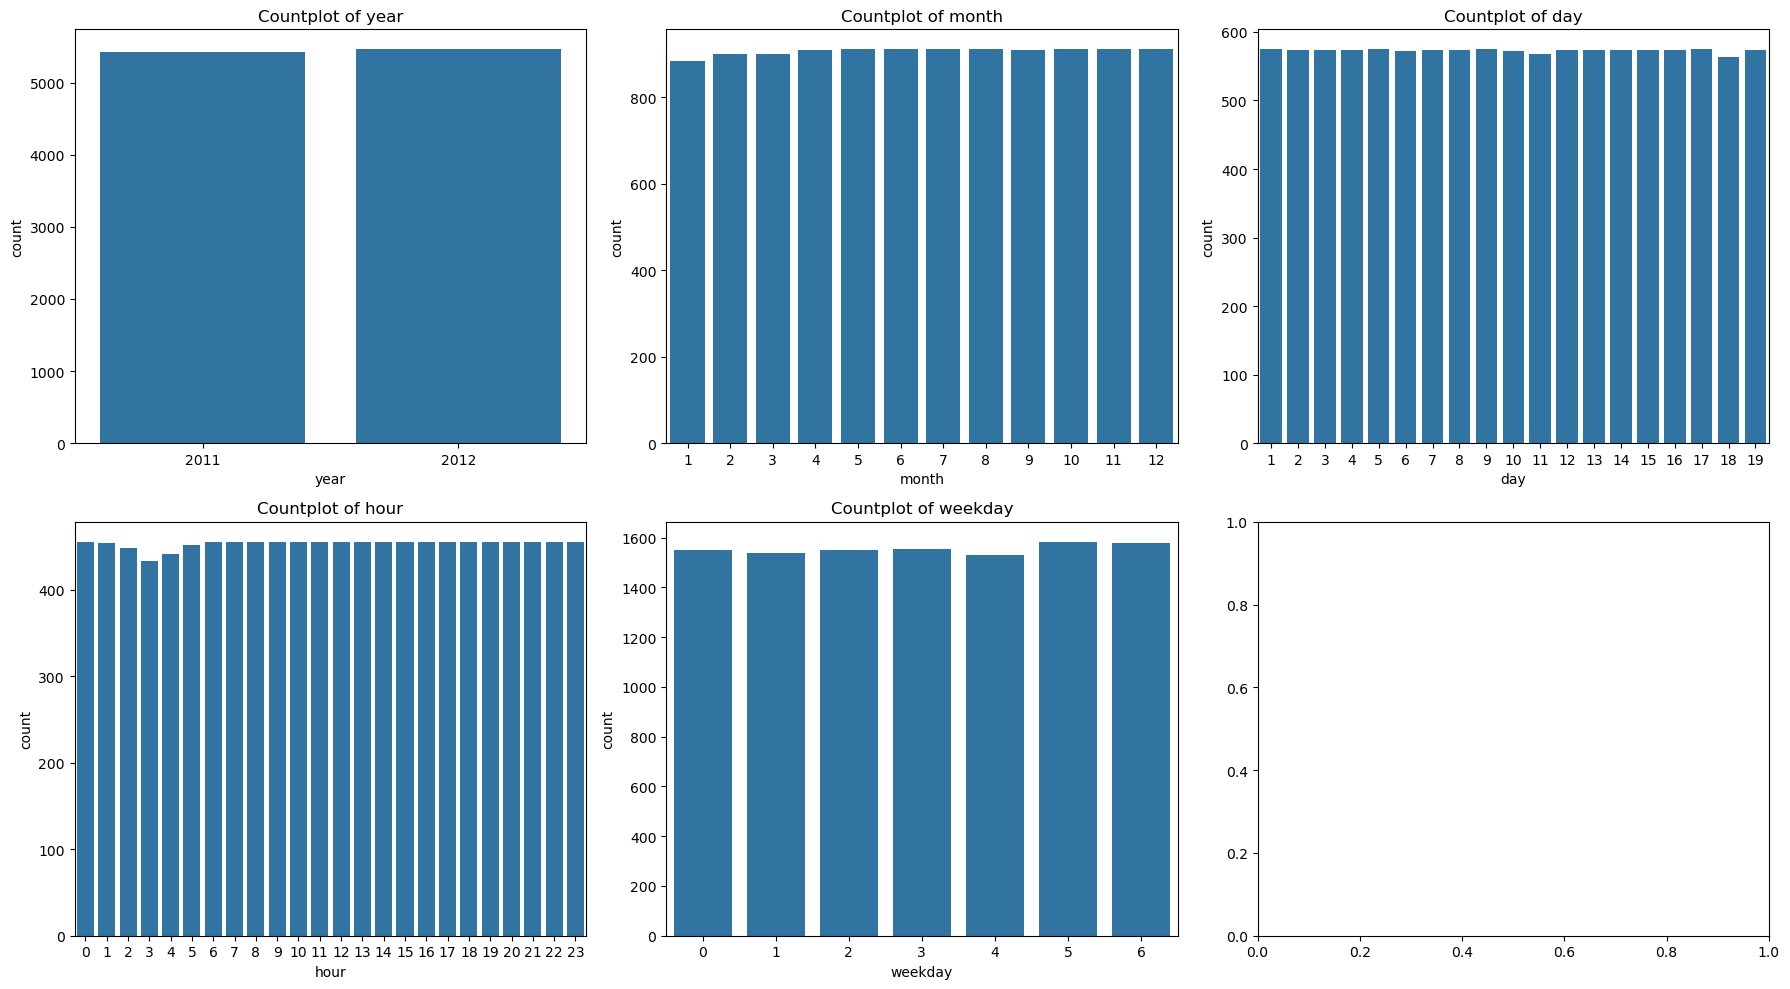

MSE : 1477.624678688705
RMSE : 38.43988395779447


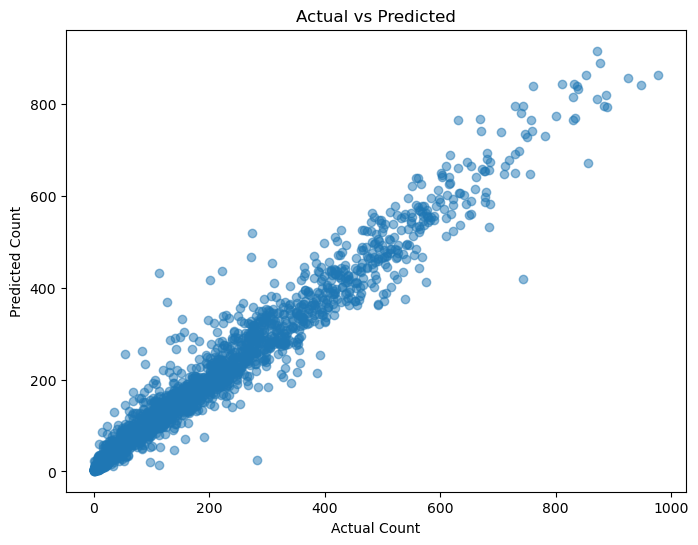

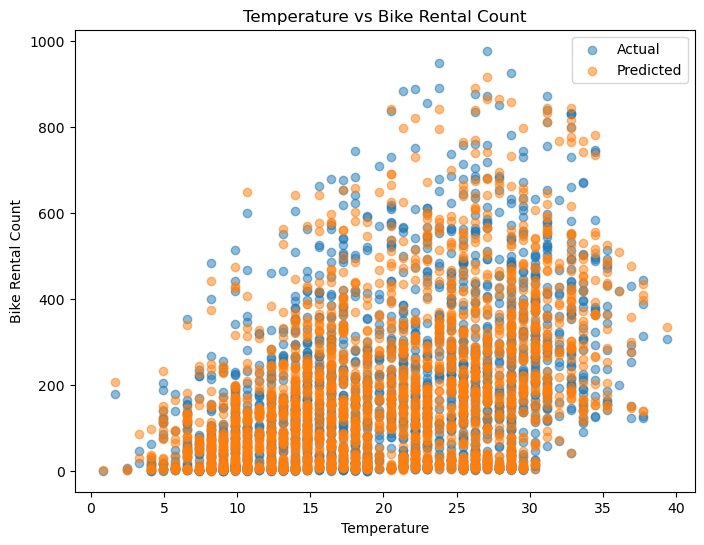

hour          0.596221
year          0.085701
workingday    0.057851
temp          0.057080
atemp         0.047312
month         0.045703
weekday       0.039192
humidity      0.026397
weather       0.014027
day           0.010515
season        0.010258
windspeed     0.007865
holiday       0.001877
dtype: float64


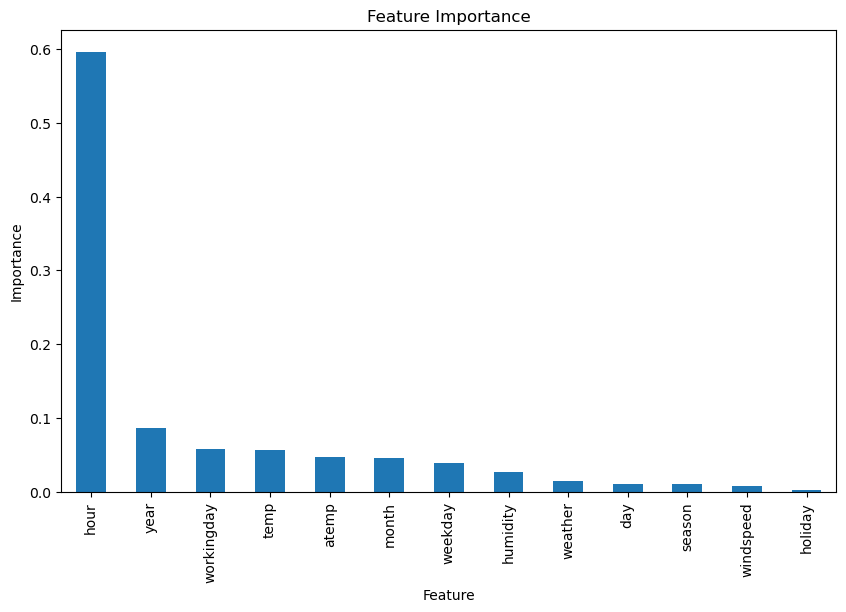

In [4]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 자전거 대여 데이터 불러오기
train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv")

# 데이터 기본 정보 확인
train.info()

# datetime 컬럼을 날짜 형식으로 변환
train['datetime'] = pd.to_datetime(train['datetime'])

# 자전거 대여량 예측에 사용할 날짜 정보 추출
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday

# 연도, 월, 일, 시간, 요일별 데이터 개수 시각화
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

cols = ['year', 'month', 'day', 'hour', 'weekday']

for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')

plt.tight_layout()
plt.show()

# 자전거 대여량 예측에 사용할 특성 선택
features = [
    'season',
    'holiday',
    'workingday',
    'weather',
    'temp',
    'atemp',
    'humidity',
    'windspeed',
    'year',
    'month',
    'day',
    'hour',
    'weekday'
]

# 입력 데이터와 정답 데이터 분리
X = train[features]
y = train['count']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 랜덤포레스트 회귀 모델 생성
model = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

# 모델 학습
model.fit(X_train, y_train)

# 자전거 대여량 예측
y_pred = model.predict(X_test)

# MSE와 RMSE 계산
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MSE :", mse)
print("RMSE :", rmse)

# 실제 대여량과 예측 대여량 비교 시각화
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted')

plt.show()

# 기온에 따른 실제 대여량과 예측 대여량 비교
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test['temp'],
    y_test,
    label='Actual',
    alpha=0.5
)

plt.scatter(
    X_test['temp'],
    y_pred,
    label='Predicted',
    alpha=0.5
)

plt.xlabel('Temperature')
plt.ylabel('Bike Rental Count')
plt.title('Temperature vs Bike Rental Count')
plt.legend()

plt.show()

# 자전거 대여량 예측에 영향을 주는 특성 확인
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))

feature_importance.plot(kind='bar')

plt.title('Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')

plt.show()